
# Experimento: Dimensiones

### Tiempo de entrenamiento de SoM (somJ) vs MiniSom en función del nº de dimensiones con 5-fold CV

In [1]:

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
from somJ.som import SoM
import somJ.config as config
import os
import time
import numpy as np
from sklearn.model_selection import KFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE
import umap
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)


/home/jaume/miniconda3/envs/tfg_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-28 19:59:55.571313: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-28 19:59:55.571784: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 19:59:55.574055: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-28 19:59:55.580292: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to r

In [2]:


# --- Parámetros ---
n_samples   = 40000
dimensions  = [10, 50, 100, 500, 1000]
n_splits    = 5
out_dir     = 'g_time_comp'
os.makedirs(out_dir, exist_ok=True)

# --- Preparar 5-fold ---
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# --- Diccionarios para acumular tiempos ---
times_som  = {d: [] for d in dimensions}
times_pca  = {d: [] for d in dimensions}
times_lda  = {d: [] for d in dimensions}
times_tsne = {d: [] for d in dimensions}
times_umap = {d: [] for d in dimensions}

for d in dimensions:
    print(f"\n=== Dimensión objetivo: {d} ===")
    rand = np.random.RandomState(0)
    train_data = rand.randint(0, 255, (n_samples, d))
    label_data = rand.randint(0, 10, (n_samples, 1))
    scaler     = MinMaxScaler()
    X_scaled   = scaler.fit_transform(train_data)

    for fold_idx, (train_idx, _) in enumerate(kf.split(X_scaled), start=1):
        X_train = X_scaled[train_idx]
        y_train = label_data[train_idx]
        print(f" Fold {fold_idx}/{n_splits}", end='… ')
        
        # SoM (somJ)
        som = SoM(
            method=config.INIT_METHOD,
            data=X_train,
            total_nodes=config.TOTAL_NODES
        )
        t0 = time.time()
        som.train(
            train_data=X_train,
            learn_rate=config.LEARNING_RATE,
            epochs=1,
            sigma=config.SIGMA,
            decay_rate=config.DECAY_RATE,
            prog_bar=False
        )
        times_som[d].append(time.time() - t0)
        # ---- PCA ----
        t0 = time.time()
        pca = PCA(n_components=2, random_state=42)
        _ = pca.fit_transform(X_train)
        times_pca[d].append(time.time() - t0)
        
        # ---- LDA ----
        t0 = time.time()
        lda = LinearDiscriminantAnalysis(n_components=2)
        _ = lda.fit_transform(X_train, y_train)
        times_lda[d].append(time.time() - t0)
        
        # ---- t-SNE ----
        t0 = time.time()
        tsne = TSNE(n_components=2, init='random', random_state=42, verbose=0)
        _ = tsne.fit_transform(X_train)
        times_tsne[d].append(time.time() - t0)
        
        # ---- UMAP ----
        t0 = time.time()
        umap_model = umap.UMAP(n_components=2, random_state=42)
        _ = umap_model.fit_transform(X_train)
        times_umap[d].append(time.time() - t0)
        
        print("OK")





=== Dimensión objetivo: 10 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Dimensión objetivo: 50 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Dimensión objetivo: 100 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Dimensión objetivo: 500 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK

=== Dimensión objetivo: 1000 ===
 Fold 1/5… OK
 Fold 2/5… OK
 Fold 3/5… OK
 Fold 4/5… OK
 Fold 5/5… OK


In [3]:
# --- Cálculo de medias y desviaciones ---
import pandas as pd

results = []
for d in dimensions:
    row = {"dims": d}
    for name, times_dict in [("SOM", times_som),
                                ("PCA", times_pca),
                             ("LDA", times_lda),
                             ("t-SNE", times_tsne),
                             ("UMAP", times_umap)]:
        arr = np.array(times_dict[d], dtype=float)
        row[f"{name}_mean"] = np.nanmean(arr)
        row[f"{name}_std"]  = np.nanstd(arr, ddof=1)
    results.append(row)

df_results = pd.DataFrame(results)
print("\nResumen de tiempos (media ± std) por técnica y dimensión:")
print(df_results.to_string(index=False))


Resumen de tiempos (media ± std) por técnica y dimensión:
 dims  SOM_mean  SOM_std  PCA_mean  PCA_std  LDA_mean  LDA_std  t-SNE_mean  t-SNE_std  UMAP_mean  UMAP_std
   10  0.585387 0.030464  0.002424 0.000274  0.032348 0.016234   57.260924   4.235287  11.974084  3.932238
   50  0.849469 0.036556  0.008078 0.001216  0.135601 0.019917   80.885642  12.588528  12.328057  0.408684
  100  1.184328 0.062475  0.017562 0.000867  0.305536 0.151589   82.160087   4.280833  12.570668  0.614661
  500  3.771079 0.216838  0.102175 0.014799  1.351745 0.307925   78.101310   4.409281  16.118379  0.412571
 1000  8.177620 0.336417  0.348806 0.050312  3.232352 0.103992   83.166959   4.221148  18.954083  0.383592


In [4]:
df_results

,dims,SOM_mean,SOM_std,PCA_mean,PCA_std,LDA_mean,LDA_std,t-SNE_mean,t-SNE_std,UMAP_mean,UMAP_std
0,10,0.585387,0.030464,0.002424,0.000274,0.032348,0.016234,57.260924,4.235287,11.974084,3.932238
1,50,0.849469,0.036556,0.008078,0.001216,0.135601,0.019917,80.885642,12.588528,12.328057,0.408684
2,100,1.184328,0.062475,0.017562,0.000867,0.305536,0.151589,82.160087,4.280833,12.570668,0.614661
3,500,3.771079,0.216838,0.102175,0.014799,1.351745,0.307925,78.101310,4.409281,16.118379,0.412571
4,1000,8.177620,0.336417,0.348806,0.050312,3.232352,0.103992,83.166959,4.221148,18.954083,0.383592


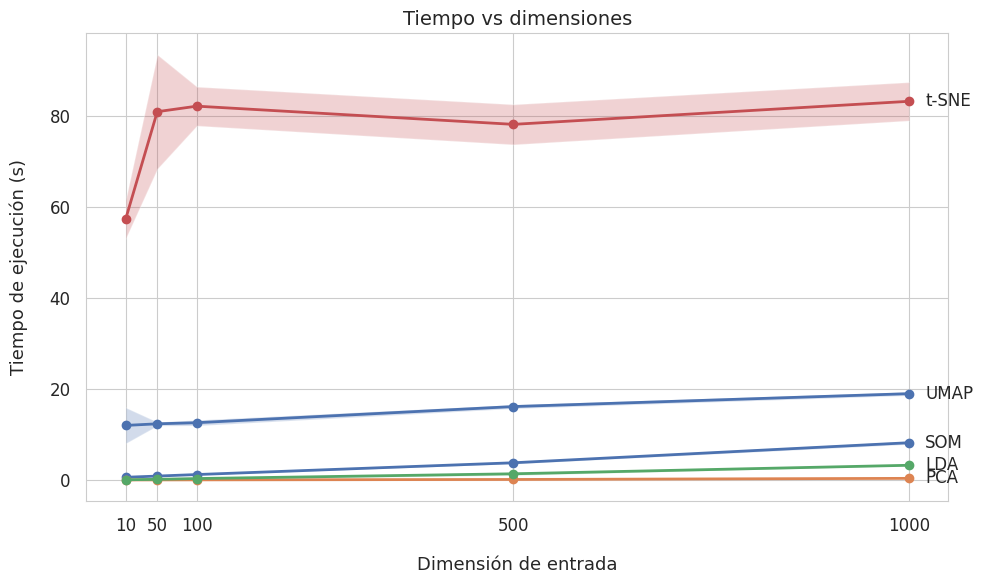

In [3]:

# --- Configuración de estilo ---
sns.set_style('whitegrid')
sns.set_palette('deep', n_colors=4)
plt.rc('font', size=12)
plt.rc('axes', titlesize=14, labelsize=13)

# --- Extraer datos de df_results ---
dims      = df_results['dims'].values
mean_som  = df_results['SOM_mean'].values
std_som   = df_results['SOM_std'].values
mean_pca  = df_results['PCA_mean'].values
std_pca   = df_results['PCA_std'].values
mean_lda  = df_results['LDA_mean'].values
std_lda   = df_results['LDA_std'].values
mean_tsne = df_results['t-SNE_mean'].values
std_tsne  = df_results['t-SNE_std'].values
mean_umap = df_results['UMAP_mean'].values
std_umap  = df_results['UMAP_std'].values

# --- Gráfica ---
fig, ax = plt.subplots(figsize=(10, 6))
fig.subplots_adjust(left=0.12, right=0.95, top=0.90, bottom=0.12)

methods = [
    ('SOM',   mean_som,   std_som),
    ('PCA',   mean_pca,   std_pca),
    ('LDA',   mean_lda,   std_lda),
    ('t-SNE', mean_tsne,  std_tsne),
    ('UMAP',  mean_umap,  std_umap),
]

for label, mean_vals, std_vals in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    std_arr  = np.array(std_vals,  dtype=float)
    valid    = ~np.isnan(mean_arr)

    ax.plot(
        dims[valid],
        mean_arr[valid],
        marker='o',
        linewidth=2,
        label=label
    )
    ax.fill_between(
        dims[valid],
        mean_arr[valid] - std_arr[valid],
        mean_arr[valid] + std_arr[valid],
        alpha=0.25
    )

# Etiquetas directas al final de cada curva
for label, mean_vals, _ in methods:
    mean_arr = np.array(mean_vals, dtype=float)
    valid_ix = np.where(~np.isnan(mean_arr))[0]
    if len(valid_ix) > 0:
        last_ix = valid_ix[-1]
        x, y = dims[last_ix], mean_arr[last_ix]
        ax.text(x * 1.02, y, label, va='center')

# Escalas y etiquetas
ax.set_xscale('linear')
ax.set_xticks(dims)
ax.tick_params(axis='x', pad=8)
ax.tick_params(axis='y', pad=8)
ax.xaxis.labelpad = 15
ax.yaxis.labelpad = 15

ax.set_xlabel('Dimensión de entrada')
ax.set_ylabel('Tiempo de ejecución (s)')
ax.set_title('Tiempo vs dimensiones')

plt.tight_layout()
plt.savefig("g_time_comp/tiempo_vs_dimensiones_5fold.png",dpi=300)
plt.show()